In [18]:
# pandas: For data loading and manipulation.
# numpy: For numerical operations and filtering.
# matplotlib and seaborn: For generating static, animated, and interactive plots.
# IPython.display: To improve output formatting in notebooks.


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Data Loading
# This ensures that once the Visualization class is instantiated, the dataset is ready for all subsequent operations.


class Visualization:
    def __init__(self):
        self.df = pd.read_csv('/content/nyc-rolling-sales.csv')
        print("Dataset loaded successfully. Shape:", self.df.shape)

        Data Analysis Pipeline

# Print the first few rows of the dataset.
# Display the overall shape (rows × columns).
# Show column names.
# This gives a quick overview of the dataset structure.

    def initial_inspection(self):
        print("\n--- Initial Data Inspection ---")
        display(self.df.head())
        print("\nShape of Data:", self.df.shape)
        print(self.df.columns.tolist())
# Print statistical summary of all numeric columns (mean, std, min, max).
# Show frequency-based description of categorical columns.
# Provides insight into data distribution and potential anomalies.

    def descriptive_statistics(self):
        print("\n--- Descriptive Statistics for Numerical Columns ---")
        display(self.df.describe())
        print("\n--- Descriptive Statistics for Categorical Columns ---")
        display(self.df.describe(include='object'))


# Identify columns with missing data.
# Display only those with null counts greater than 0.
# Understanding missing data is critical for effective preprocessing and modeling.

    def check_missing_values(self):
        print("\n--- Missing Values ---")
        missing = self.df.isnull().sum()
        display(missing[missing > 0])

# Calculate correlations between numeric features.
# Visualize correlation matrix using a heatmap.
# : Helps identify multicollinearity and strong associations between features.


    def correlation_matrix(self):
        print("\n--- Correlation Matrix ---")
        numeric_cols = self.df.select_dtypes(include=np.number)
        corr = numeric_cols.corr()
        display(corr)
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
        plt.title("Correlation Matrix")
        plt.show()


# Generate histograms of all numeric features.
# : Visualizing distributions helps detect skewness, outliers, and spread.

    def data_distributions(self):
        print("\n--- Data Distributions ---")
        numeric_cols = self.df.select_dtypes(include=np.number).columns
        self.df[numeric_cols].hist(bins=15, figsize=(15, 10), layout=(4, 4))
        plt.tight_layout()
        plt.show()


# Create scatter plots comparing each numeric feature to the last numeric column.
# : Useful for spotting linear or nonlinear trends and potential relationships.

    def scatter_plots(self):
        print("\n--- Scatter Plots ---")
        numeric_cols = self.df.select_dtypes(include=np.number).columns
        if len(numeric_cols) < 2:
            print("Not enough numerical columns for scatter plots.")
            return
        for i, col in enumerate(numeric_cols[:-1]):
            plt.figure(figsize=(6, 4))
            sns.scatterplot(data=self.df, x=col, y=numeric_cols[-1])
            plt.title(f"Scatter Plot: {col} vs {numeric_cols[-1]}")
            plt.show()


# Create bar plots of the top 10 most frequent values for each categorical column.
# : Analyzing category distributions helps detect class imbalance and rare classes.


    def bar_charts(self):
        print("\n--- Bar Charts ---")
        cat_cols = self.df.select_dtypes(include='object').columns
        for col in cat_cols:
            plt.figure(figsize=(8, 4))
            self.df[col].value_counts().head(10).plot(kind='bar')
            plt.title(f"Bar Chart of {col}")
            plt.xlabel(col)
            plt.ylabel("Count")
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()


# Plot box plots for all numeric columns.
# : Detects outliers, distribution spread, and quartiles visually.


    def box_plots(self):
        print("\n--- Box Plots ---")
        numeric_cols = self.df.select_dtypes(include=np.number).columns
        for col in numeric_cols:
            plt.figure(figsize=(6, 4))
            sns.boxplot(y=self.df[col])
            plt.title(f"Box Plot of {col}")
            plt.show()


# Plot Kernel Density Estimates (smoothed histograms) for numeric features.
# : Better visualization of underlying distributions, particularly for skewed data.

    def density_plots(self):
        print("\n--- Density Plots ---")
        numeric_cols = self.df.select_dtypes(include=np.number).columns
        for col in numeric_cols:
            plt.figure(figsize=(6, 4))
            sns.kdeplot(data=self.df, x=col, fill=True)
            plt.title(f"Density Plot of {col}")
            plt.show()

# Visualize the relationship between the target column and all other features.
# Numeric vs. Target → Box plots
# Categorical vs. Target → Count plots
# : Crucial for understanding how features vary across different classes or outcomes.

    def analyze_target_relationship(self, target):
        print(f"\n--- Relationship of Target '{target}' with Other Columns ---")
        for col in self.df.columns:
            if col == target:
                continue
            plt.figure(figsize=(6, 4))
            if self.df[col].dtype in ['int64', 'float64']:
                sns.boxplot(x=self.df[target], y=self.df[col])
                plt.title(f"{target} vs {col} (Box Plot)")
            else:
                sns.countplot(data=self.df, x=col, hue=self.df[target])
                plt.title(f"{target} vs {col} (Count Plot)")
                plt.xticks(rotation=45, ha = 'right')
            plt.tight_layout()
            plt.show()

#Executes the entire EDA pipeline in order.
# Includes target relationship analysis if a target is specified.
# : Provides a comprehensive, one-stop function to run all EDA steps in sequence.

    def full_analysis(self, target=None):
        self.initial_inspection()
        self.descriptive_statistics()
        self.check_missing_values()
        self.correlation_matrix()
        self.data_distributions()
        self.scatter_plots()
        self.bar_charts()
        self.box_plots()
        self.density_plots()
        if target:
            self.analyze_target_relationship(target)

Dataset loaded successfully. Shape: (84548, 22)

--- Initial Data Inspection ---


,Unnamed: 0,BOROUGH,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,BLOCK,LOT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,...,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,LAND SQUARE FEET,GROSS SQUARE FEET,YEAR BUILT,TAX CLASS AT TIME OF SALE,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
0,4,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,392,6,,C2,153 AVENUE B,...,5,0,5,1633,6440,1900,2,C2,6625000,2017-07-19 00:00:00
1,5,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,26,,C7,234 EAST 4TH STREET,...,28,3,31,4616,18690,1900,2,C7,-,2016-12-14 00:00:00
2,6,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2,399,39,,C7,197 EAST 3RD STREET,...,16,1,17,2212,7803,1900,2,C7,-,2016-12-09 00:00:00
3,7,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2B,402,21,,C4,154 EAST 7TH STREET,...,10,0,10,2272,6794,1913,2,C4,3936272,2016-09-23 00:00:00
4,8,1,ALPHABET CITY,07 RENTALS - WALKUP APARTMENTS,2A,404,55,,C2,301 EAST 10TH STREET,...,6,0,6,2369,4615,1900,2,C2,8000000,2016-11-17 00:00:00



Shape of Data: (84548, 22)
['Unnamed: 0', 'BOROUGH', 'NEIGHBORHOOD', 'BUILDING CLASS CATEGORY', 'TAX CLASS AT PRESENT', 'BLOCK', 'LOT', 'EASE-MENT', 'BUILDING CLASS AT PRESENT', 'ADDRESS', 'APARTMENT NUMBER', 'ZIP CODE', 'RESIDENTIAL UNITS', 'COMMERCIAL UNITS', 'TOTAL UNITS', 'LAND SQUARE FEET', 'GROSS SQUARE FEET', 'YEAR BUILT', 'TAX CLASS AT TIME OF SALE', 'BUILDING CLASS AT TIME OF SALE', 'SALE PRICE', 'SALE DATE']

--- Descriptive Statistics for Numerical Columns ---


,Unnamed: 0,BOROUGH,BLOCK,LOT,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,YEAR BUILT,TAX CLASS AT TIME OF SALE
count,84548.000000,84548.000000,84548.000000,84548.000000,84548.000000,84548.000000,84548.000000,84548.000000,84548.000000,84548.000000
mean,10344.359878,2.998758,4237.218976,376.224015,10731.991614,2.025264,0.193559,2.249184,1789.322976,1.657485
std,7151.779436,1.289790,3568.263407,658.136814,1290.879147,16.721037,8.713183,18.972584,537.344993,0.819341
min,4.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4231.000000,2.000000,1322.750000,22.000000,10305.000000,0.000000,0.000000,1.000000,1920.000000,1.000000
50%,8942.000000,3.000000,3311.000000,50.000000,11209.000000,1.000000,0.000000,1.000000,1940.000000,2.000000
75%,15987.250000,4.000000,6281.000000,1001.000000,11357.000000,2.000000,0.000000,2.000000,1965.000000,2.000000
max,26739.000000,5.000000,16322.000000,9106.000000,11694.000000,1844.000000,2261.000000,2261.000000,2017.000000,4.000000



--- Descriptive Statistics for Categorical Columns ---


,NEIGHBORHOOD,BUILDING CLASS CATEGORY,TAX CLASS AT PRESENT,EASE-MENT,BUILDING CLASS AT PRESENT,ADDRESS,APARTMENT NUMBER,LAND SQUARE FEET,GROSS SQUARE FEET,BUILDING CLASS AT TIME OF SALE,SALE PRICE,SALE DATE
count,84548,84548,84548,84548,84548,84548,84548,84548,84548,84548,84548,84548
unique,254,47,11,1,167,67563,3989,6062,5691,166,10008,364
top,FLUSHING-NORTH,01 ONE FAMILY DWELLINGS,1,,D4,131-05 40TH ROAD,,-,-,R4,-,2017-06-29 00:00:00
freq,3068,18235,38633,84548,12663,210,65496,26252,27612,12989,14561,544



--- Missing Values ---


,0



--- Correlation Matrix ---


,Unnamed: 0,BOROUGH,BLOCK,LOT,ZIP CODE,RESIDENTIAL UNITS,COMMERCIAL UNITS,TOTAL UNITS,YEAR BUILT,TAX CLASS AT TIME OF SALE
Unnamed: 0,1.000000,0.088817,0.264130,-0.031601,0.166882,-0.013318,-0.002821,-0.012856,-0.004057,0.017395
BOROUGH,0.088817,1.000000,0.417001,-0.277848,0.256564,-0.023229,-0.005503,-0.023346,0.108303,-0.315163
BLOCK,0.264130,0.417001,1.000000,-0.229118,0.234063,-0.015628,-0.003517,-0.015888,0.071262,-0.287300
LOT,-0.031601,-0.277848,-0.229118,1.000000,-0.145802,-0.034303,-0.010953,-0.033169,-0.289463,0.296680
ZIP CODE,0.166882,0.256564,0.234063,-0.145802,1.000000,0.005578,0.000726,0.005415,0.330708,-0.142915
RESIDENTIAL UNITS,-0.013318,-0.023229,-0.015628,-0.034303,0.005578,1.000000,0.015653,0.888309,0.025380,-0.001074
COMMERCIAL UNITS,-0.002821,-0.005503,-0.003517,-0.010953,0.000726,0.015653,1.000000,0.472998,0.006428,0.049586
TOTAL UNITS,-0.012856,-0.023346,-0.015888,-0.033169,0.005415,0.888309,0.472998,1.000000,0.024568,0.026429
YEAR BUILT,-0.004057,0.108303,0.071262,-0.289463,0.330708,0.025380,0.006428,0.024568,1.000000,-0.187609
TAX CLASS AT TIME OF SALE,0.017395,-0.315163,-0.287300,0.296680,-0.142915,-0.001074,0.049586,0.026429,-0.187609,1.000000


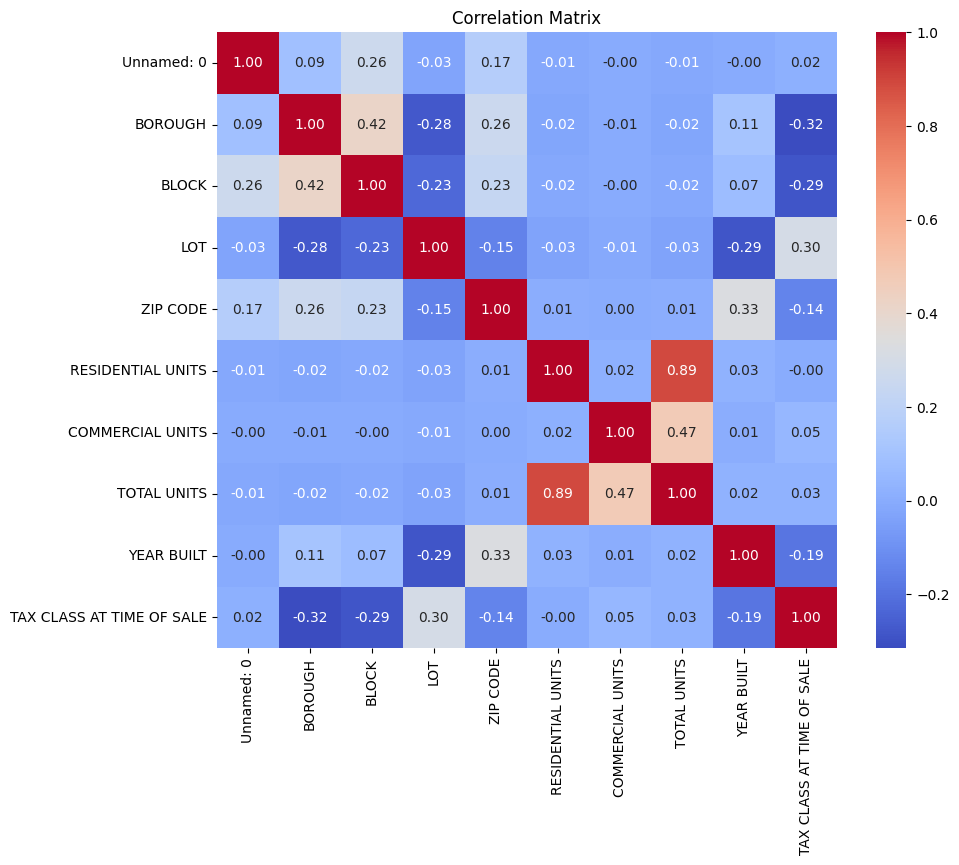


--- Data Distributions ---


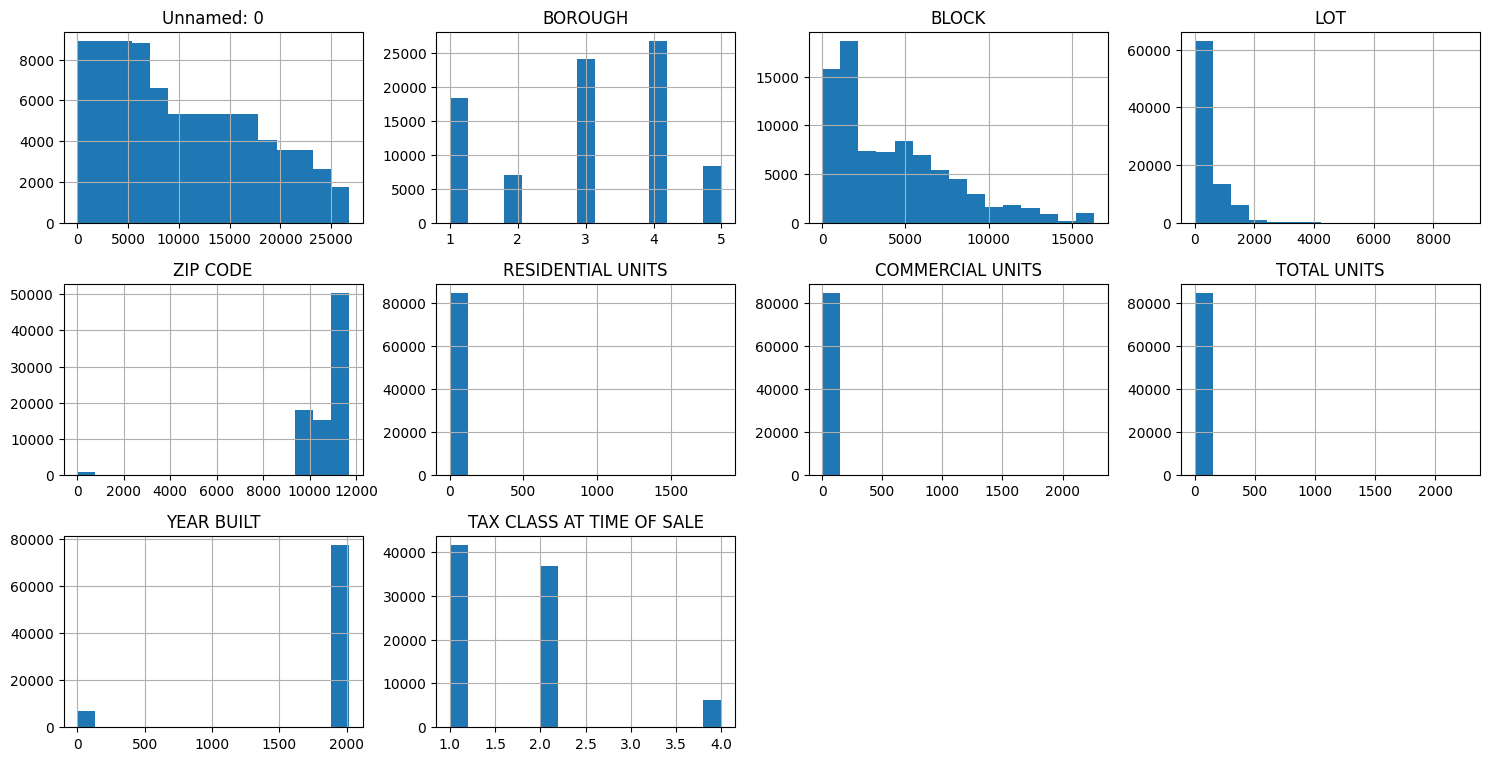


--- Scatter Plots ---


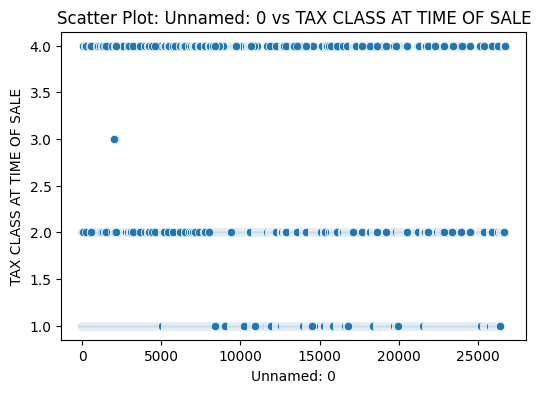

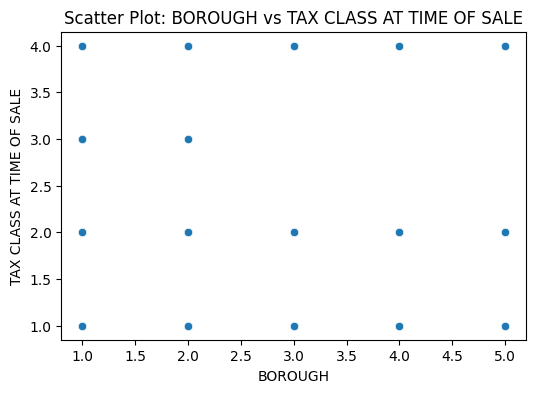

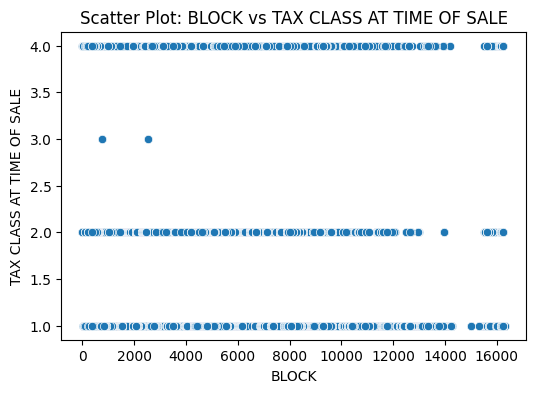

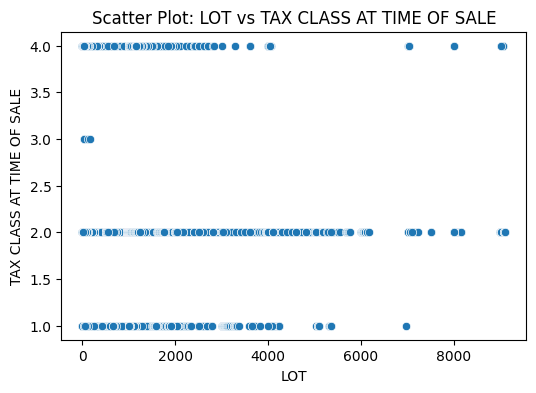

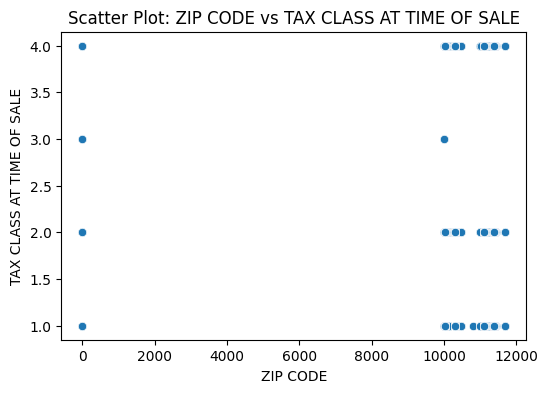

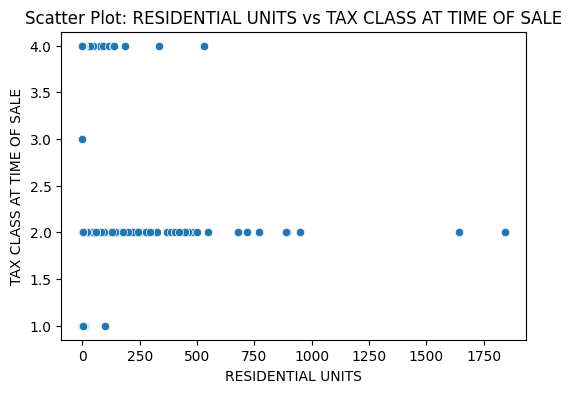

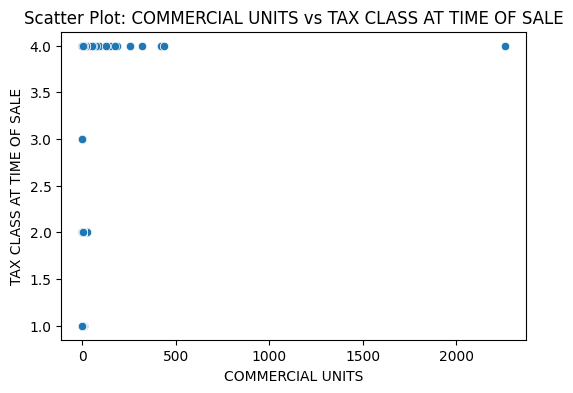

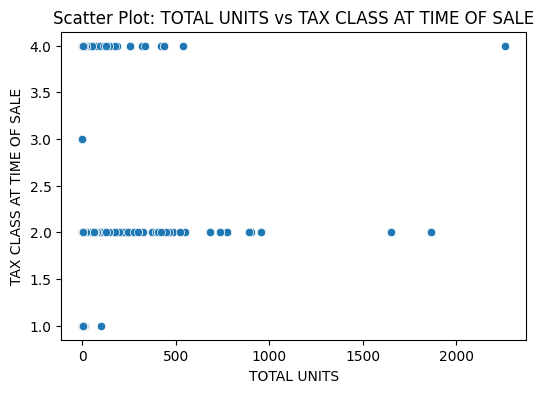

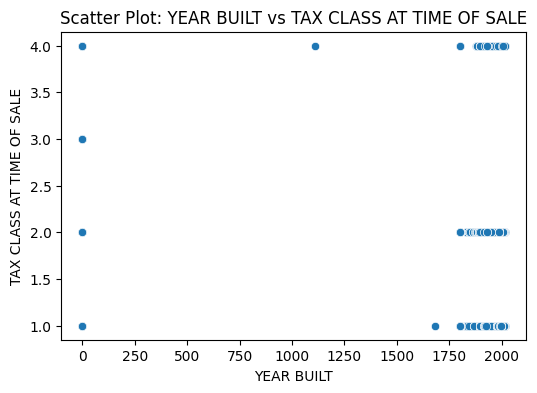


--- Bar Charts ---


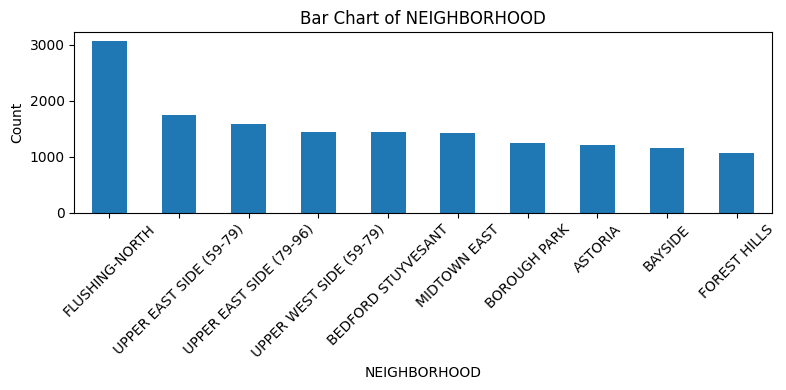

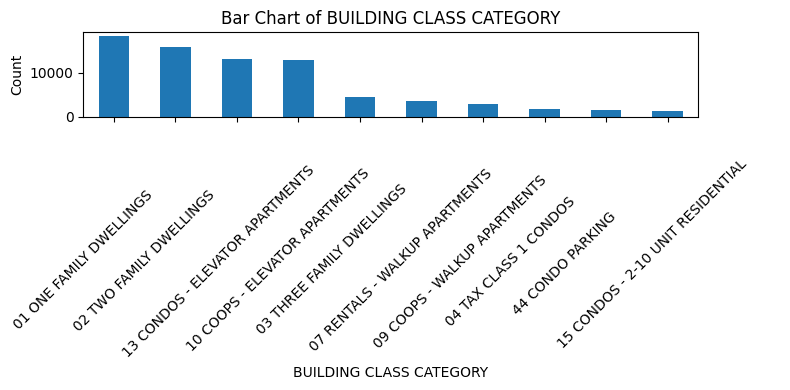

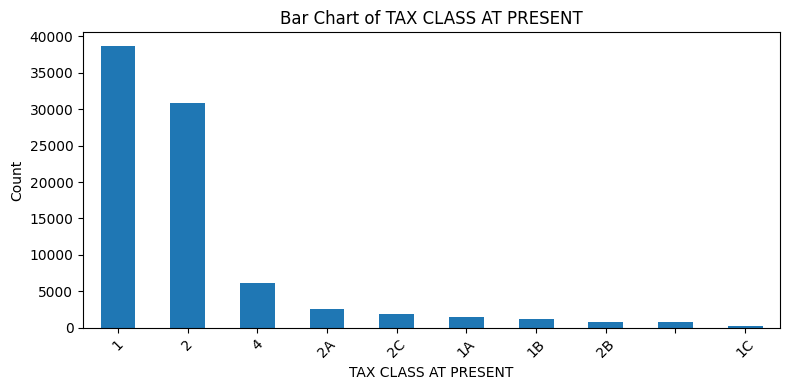

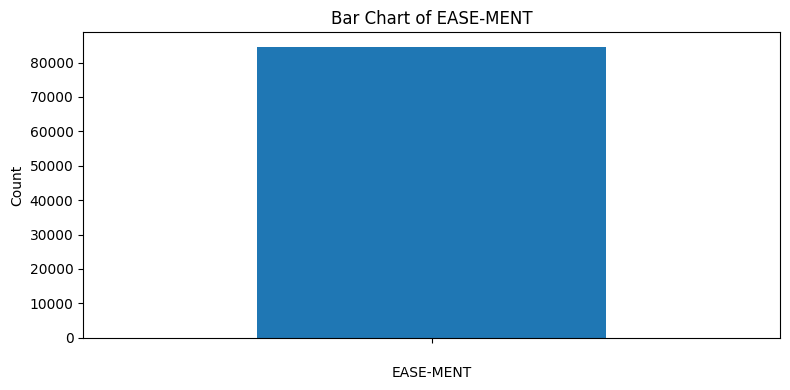

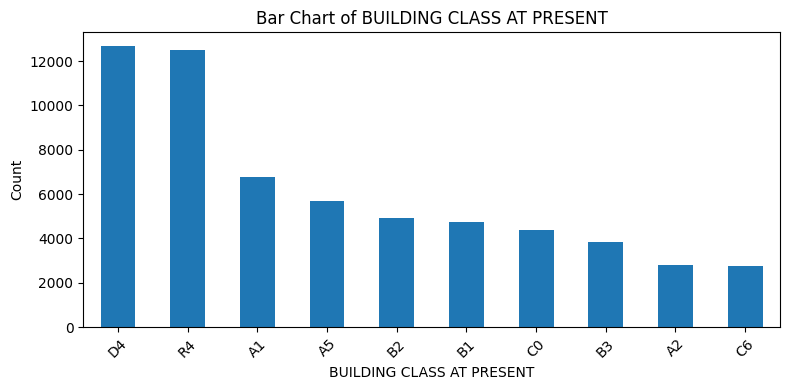

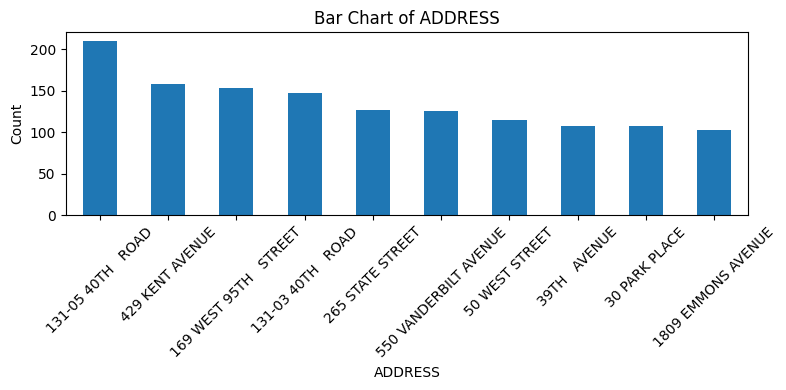

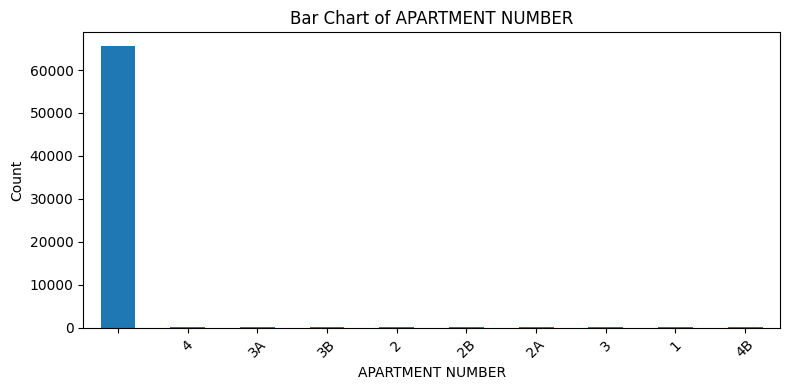

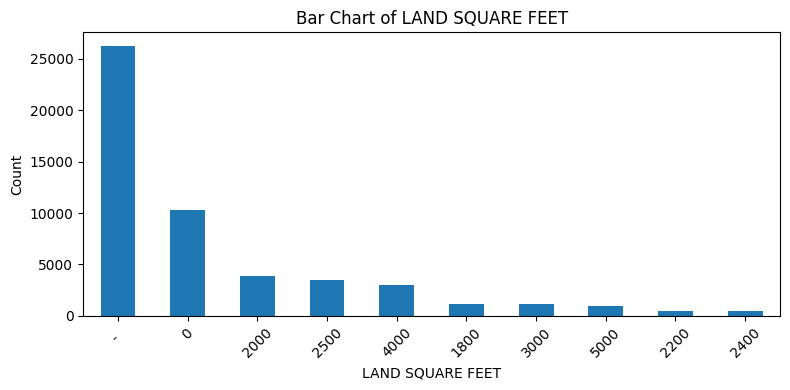

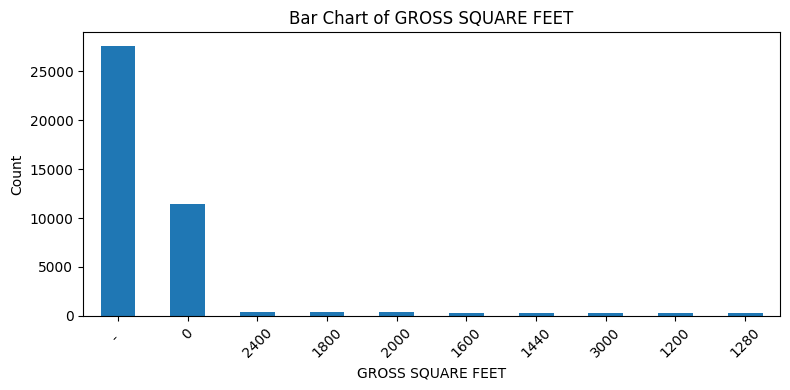

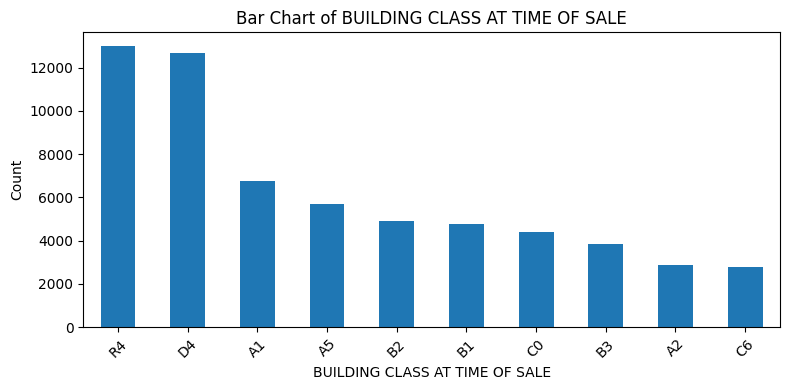

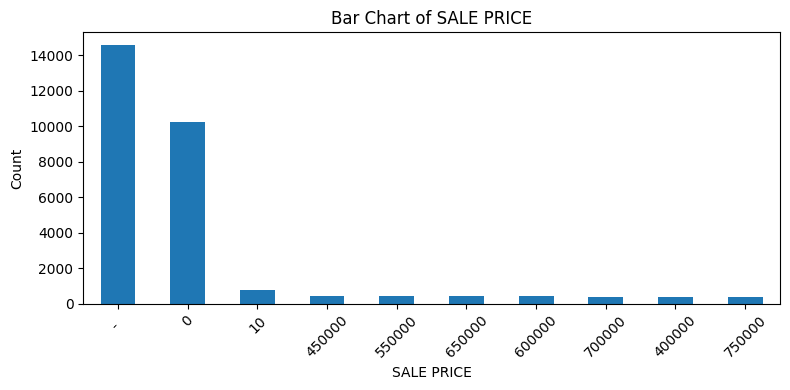

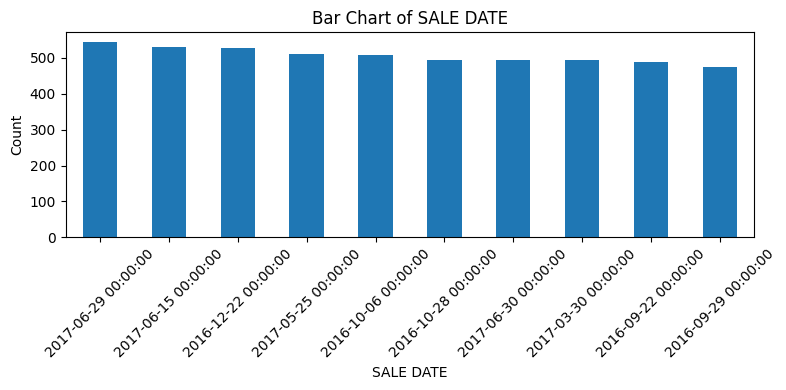


--- Box Plots ---


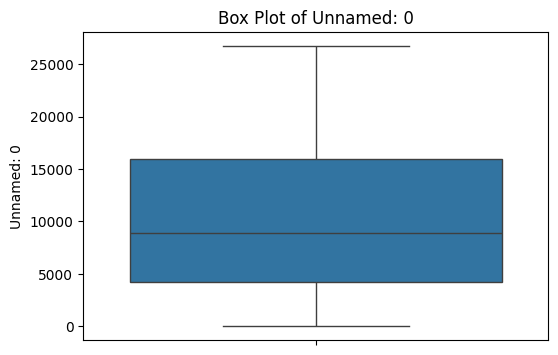

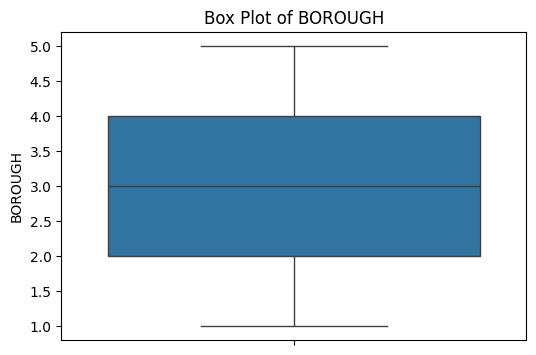

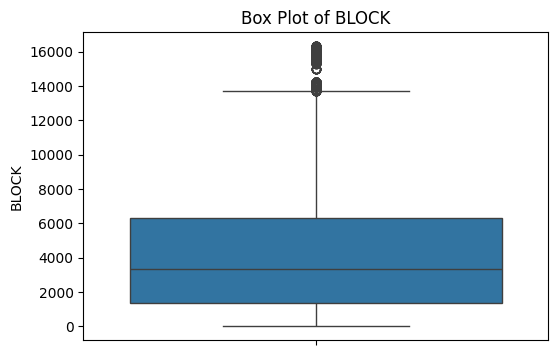

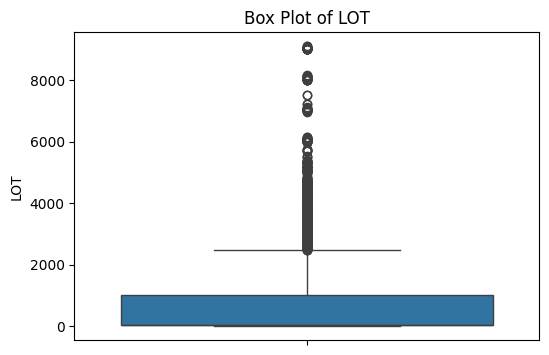

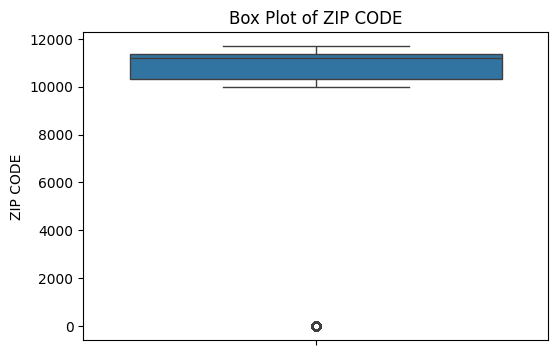

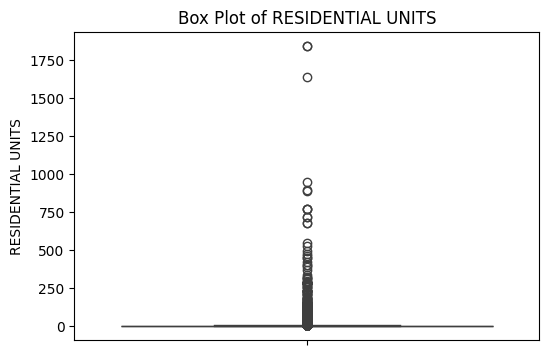

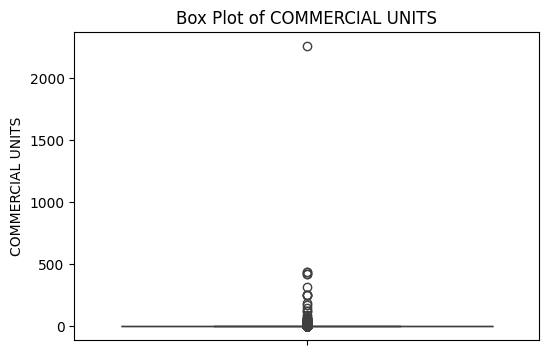

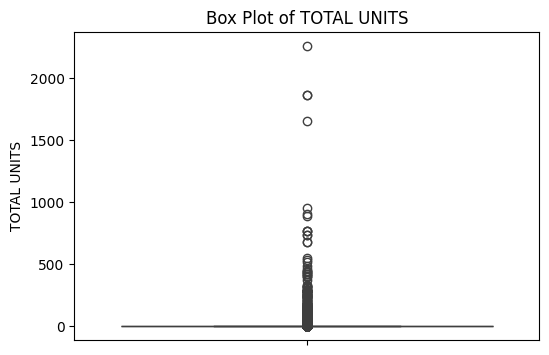

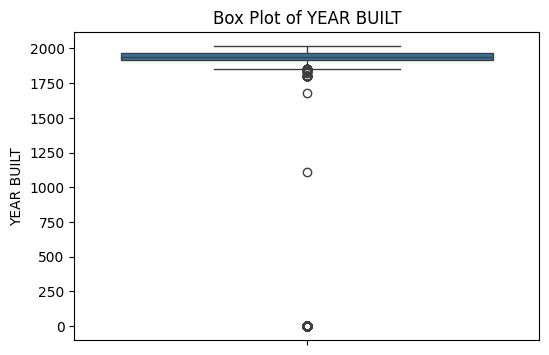

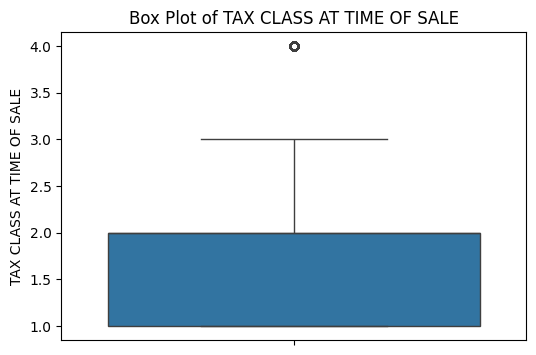


--- Density Plots ---


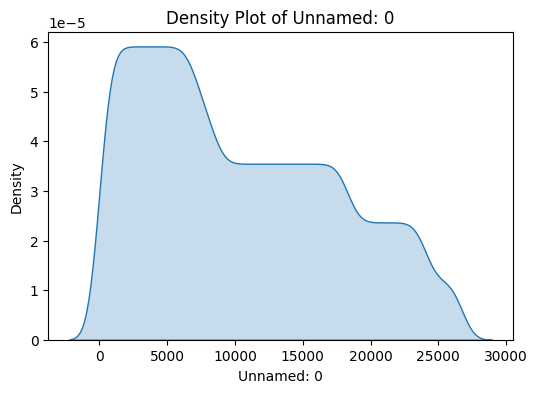

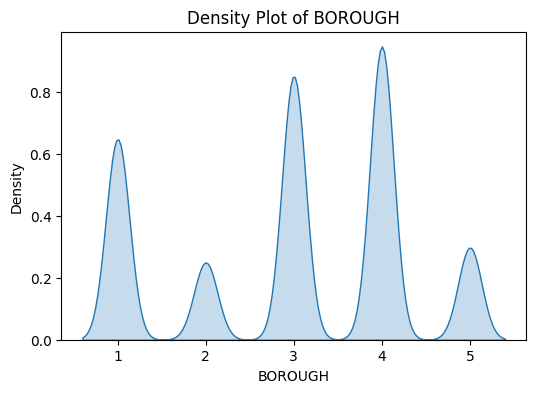

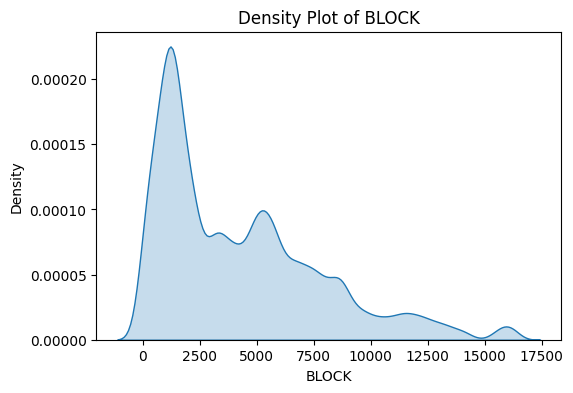

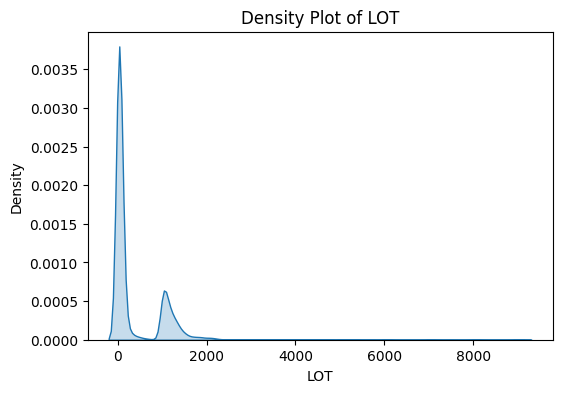

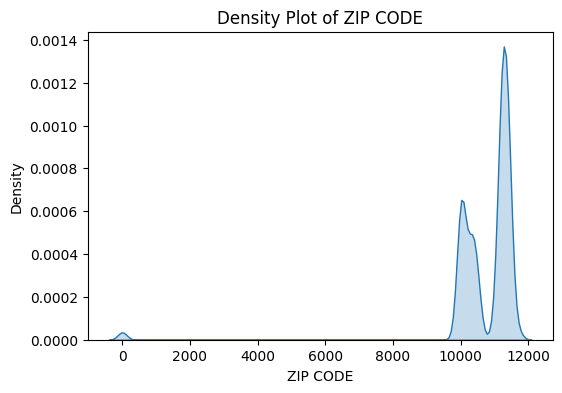

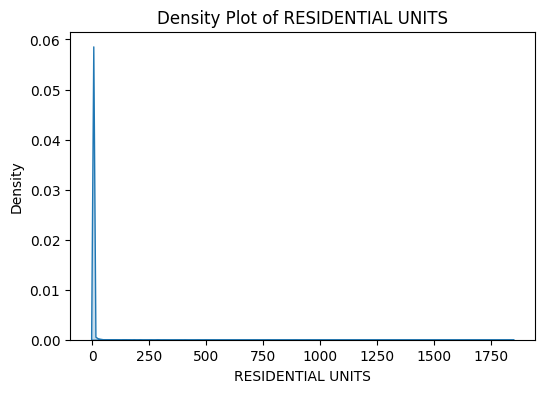

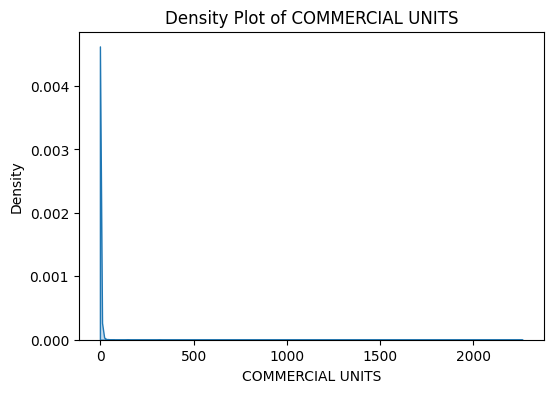

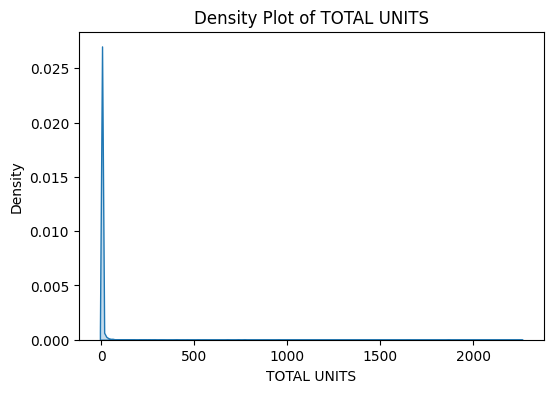

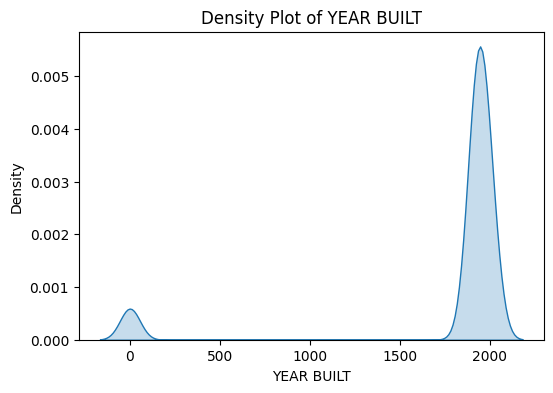

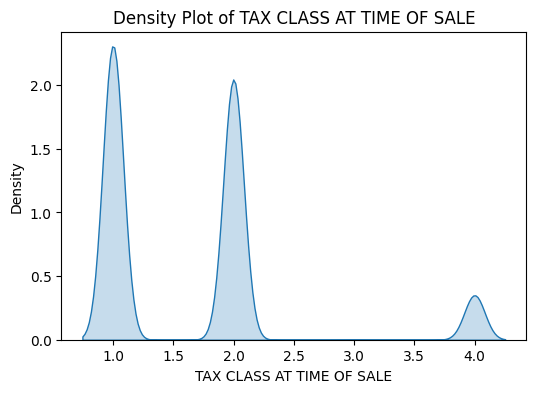

In [20]:

# Once the Visualization class is defined, you can create an instance and invoke any method as needed.
# This provides flexibility to perform specific analysis tasks or run the full EDA pipeline with an optional target column.


viz = Visualization()
viz.initial_inspection()
viz.descriptive_statistics()
viz.check_missing_values()
viz.correlation_matrix()
viz.data_distributions()
viz.scatter_plots()
viz.bar_charts()
viz.box_plots()
viz.density_plots()

#viz.full_analysis(target='BUILDING CLASS CATEGORY')  # Optional: use a real target column